# Investigación del asesinato en SQL City



#### Paso 1. Recuperar todos los registros de crímenes de tipo "asesinato" cometidos en SQL City

<blockquote>SELECT * FROM crime_scene_report WHERE city = 'SQL City' AND type = 'murder';</blockquote>

Esto nos devuelve 3 resultados, de los cuales sólo uno de ellos nos aporta información útil

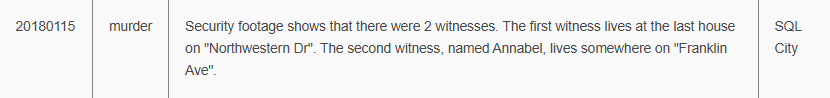


#### Paso 2. Encontrar a los testigos en base a los datos del reporte del crimen

<blockquote>SELECT * FROM person WHERE address_street_name = 'Franklin Ave' OR address_street_name = 'Northwestern Dr';</blockquote>

Esto nos devuelve todas las personas que residen en las dos direcciones mencionadas en el reporte, pero es un resultado demasiado amplio.
También tenemos el nombre de uno de los testigos, Annabel.

<blockquote>SELECT * FROM person WHERE address_street_name = 'Franklin Ave' AND name LIKE '%Annabel%';</blockquote>

Ahora ya tenemos la identidad completa de uno de los testigos.

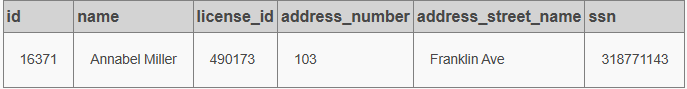


#### Paso 3. Averiguar qué sabe el testigo sobre el crimen

<blockquote>SELECT * FROM interview WHERE person_id = (SELECT id FROM person WHERE address_street_name = 'Franklin Ave' AND name LIKE '%Annabel%');</blockquote>

Aprovechando el resultado de la query anterior, podemos usarlo directamente en la siguiente para encontrar el reporte de la entrevista de este testigo en base a su id.

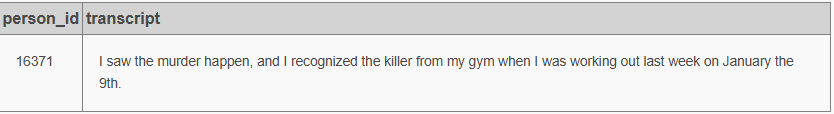


#### Paso 4. Ubicar al sospechoso a partir del registro de entradas del gimnasio

<blockquote>SELECT * FROM get_fit_now_check_in WHERE membership_id = (SELECT id FROM get_fit_now_member WHERE name LIKE '%Annabel%');</blockquote>

Siguiendo el mismo método que el paso anterior, podemos encontrar el registro de entrada de nuestro testigo a partir de su id de miembro del gimnasio.

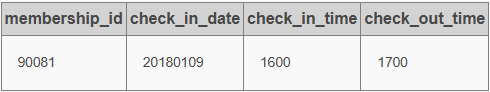

 Con esa información podemos acotar la búsqueda del resto de miembros que estaban presentes en el gimnasio en la fecha y hora recuperadas.

 <blockquote>SELECT * FROM get_fit_now_check_in WHERE check_in_date = 20180109 AND check_in_time <= 1600 AND check_out_time >= 1700;</blockquote>

 Ya hemos acotado los resultados a los usuarios que estaban en el gimnasio en la misma franja de tiempo que nuestro testigo.

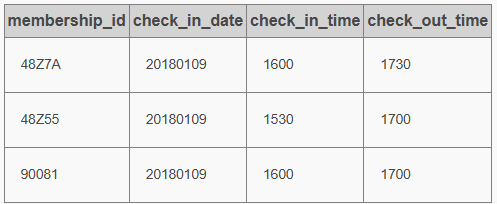

 Y ahora podemos conocer sus identidades.

 <blockquote>SELECT * FROM person WHERE id = (SELECT person_id FROM get_fit_now_member WHERE id = '48Z7A') OR id = (SELECT person_id FROM get_fit_now_member WHERE id = '48Z55');</blockquote>

 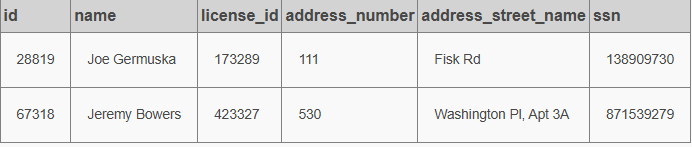


#### Paso 5. Analizar las entrevistas de los sospechosos

<blockquote>SELECT * FROM interview WHERE person_id = (SELECT person_id FROM get_fit_now_member WHERE id = '48Z7A') OR person_id = (SELECT person_id FROM get_fit_now_member WHERE id = '48Z55');</blockquote>

Haciendo una búsqueda en la tabla de entrevistas filtrando por los IDs de ambos sospechosos, encontramos una coincidencia para uno de ellos

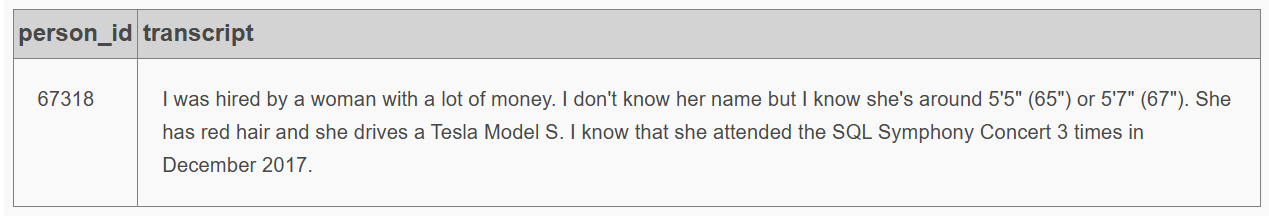


#### Paso 6. Atando cabos

Según la información obtenida de la entrevista, el primer paso lógico es buscar en la tabla de permisos de circulación, filtrando por el rango de estatura, el color de pelo y la marca y modelo de coche. Después necesitamos relacionar esos resultados con el resto de la información (mujer, con mucho dinero y que atendió al SQL Symphony 3 veces en 2017). Hará falta una sentencia compleja para conseguirlo.

<blockquote>SELECT p.name, fb.* </br>
FROM facebook_event_checkin fb </br>
JOIN person p ON fb.person_id=p.id </br>
WHERE event_name LIKE '%symphony%' </br>
AND date BETWEEN 20170101 AND 20171231 </br>
AND person_id IN (SELECT i.*, p.name </br>
FROM income i </br>
JOIN person p ON i.ssn=p.ssn </br>
WHERE i.ssn IN (SELECT ssn </br>
FROM person </br>
WHERE license_id IN (SELECT id </br>
FROM drivers_license </br>
WHERE height BETWEEN 65 AND 67 </br>
AND hair_color = 'red' </br>
AND car_make = 'Tesla' </br>
AND car_model = 'Model S')));
</blockquote>

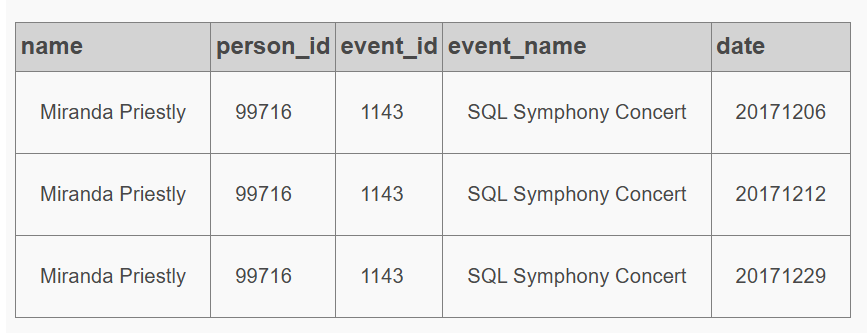

Y con ésto, tenemos a nuestra asesina.

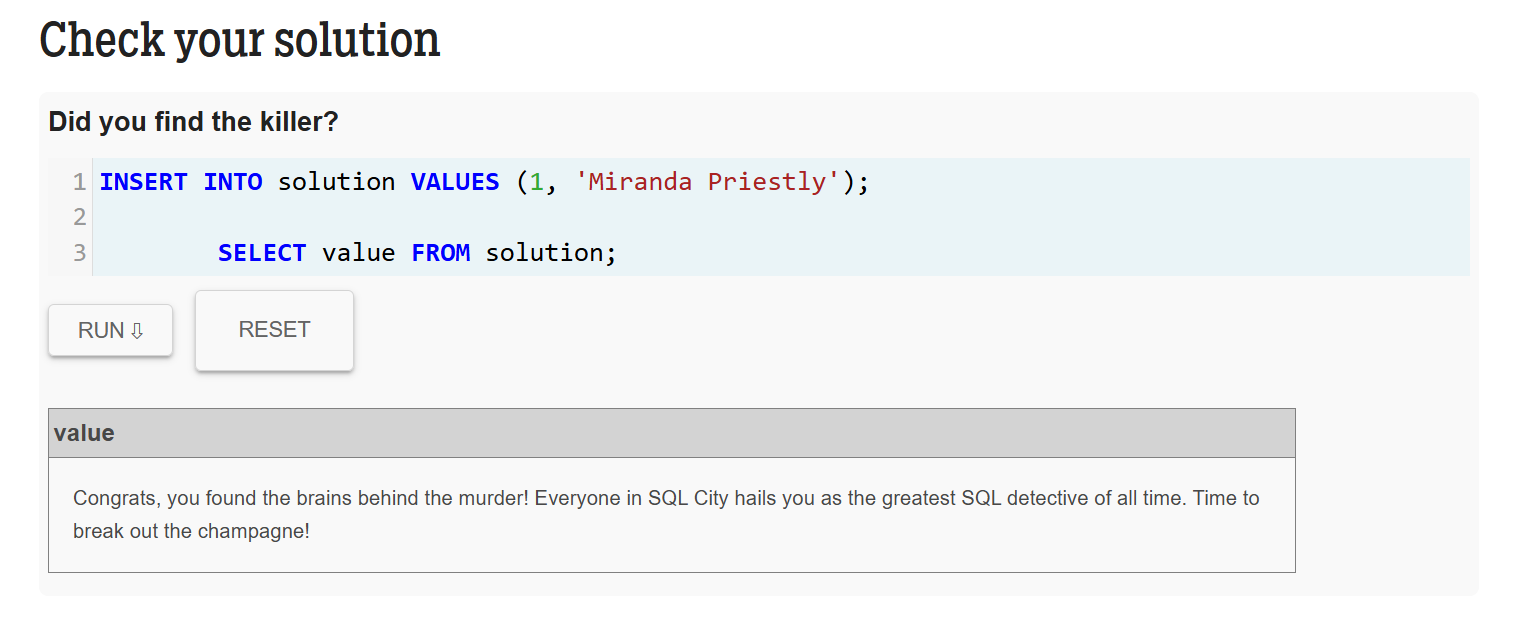
